Total contacts found: 17
                     Start                    Stop  Duration_s
0  2025-01-01 00:23:10.089 2025-01-01 00:31:25.736  495.646512
1  2025-01-01 01:59:44.272 2025-01-01 02:06:31.061  406.789270
2  2025-01-01 18:40:07.309 2025-01-01 18:46:03.812  356.502951
3  2025-01-01 20:14:42.427 2025-01-01 20:22:52.794  490.366933
4  2025-01-01 21:50:55.092 2025-01-01 21:59:10.801  495.708999
5  2025-01-01 23:27:17.568 2025-01-01 23:35:35.362  497.793167
6  2025-01-02 01:03:38.706 2025-01-02 01:11:18.040  459.333496
7  2025-01-02 17:46:01.510 2025-01-02 17:49:06.803  185.292206
8  2025-01-02 19:19:06.135 2025-01-02 19:26:57.758  471.623178
9  2025-01-02 20:54:59.788 2025-01-02 21:03:16.689  496.901471
10 2025-01-02 22:31:24.240 2025-01-02 22:39:40.720  496.479989
11 2025-01-03 00:07:41.803 2025-01-03 00:15:47.110  485.306781
12 2025-01-03 01:44:47.912 2025-01-03 01:49:53.594  305.681957
13 2025-01-03 18:23:44.876 2025-01-03 18:30:56.584  431.707851
14 2025-01-03 19:59:07.485 202

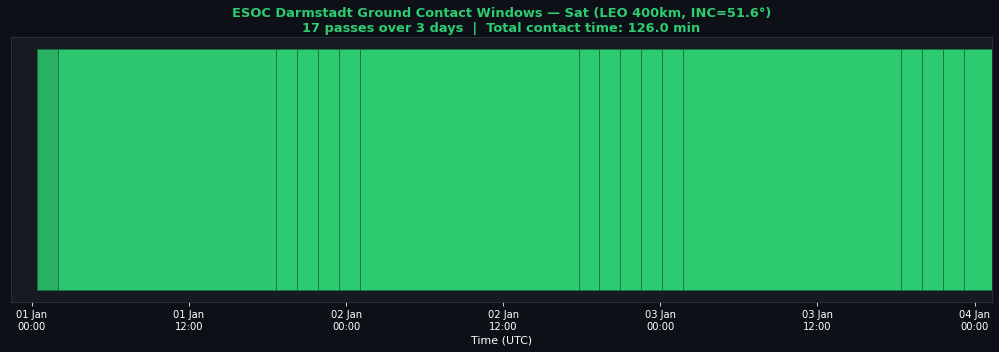


Average pass duration: 444.8 sec (7.4 min)
Longest pass:  497.8 sec
Shortest pass: 185.3 sec

Longest gap with no contact: 16.58 hours
Average gap between passes:  4.30 hours


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import os

output_dir = r'D:\Space Softwares\GMAT Project\ESOC Ground Station Coverage\Output'
filepath = os.path.join(output_dir, 'ESOC_contacts.txt')

def parse_contact_file(filepath):
    rows = []
    with open(filepath, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line:
            continue
        parts = line.split()

        # A valid data line has EXACTLY 9 tokens: 4 (start) + 4 (stop) + 1 (duration)
        if len(parts) != 9:
            continue

        # Extra safety: token[1] must be a 3-letter month abbreviation
        months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
        if parts[1] not in months:
            continue

        start_str = ' '.join(parts[0:4])
        stop_str  = ' '.join(parts[4:8])
        duration  = float(parts[8])

        start_dt = datetime.strptime(start_str, '%d %b %Y %H:%M:%S.%f')
        stop_dt  = datetime.strptime(stop_str,  '%d %b %Y %H:%M:%S.%f')

        rows.append({'Start': start_dt, 'Stop': stop_dt, 'Duration_s': duration})

    return pd.DataFrame(rows)

df = parse_contact_file(filepath)
print(f'Total contacts found: {len(df)}')
print(df)
print(f'\nDate range: {df["Start"].min()} to {df["Start"].max()}')

# ── PLOT: Timeline bar chart, zoomed to actual data range ──────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0D1117')
ax.set_facecolor('#161B22')

for i, row in df.iterrows():
    ax.barh(0, (row['Stop'] - row['Start']).total_seconds() / 60,
            left=mdates.date2num(row['Start']),
            height=0.5, color='#2ECC71', edgecolor='#1A6B3A', alpha=0.85)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))
ax.set_yticks([])
ax.set_xlabel('Time (UTC)', color='white', fontsize=11)
ax.set_title(f'ESOC Darmstadt Ground Contact Windows — Sat (LEO 400km, INC=51.6°)\n'
             f'{len(df)} passes over 3 days  |  Total contact time: {df["Duration_s"].sum()/60:.1f} min',
             color='#2ECC71', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363D')

# Auto-fit the x-axis tightly to the actual data range, with small padding
pad = pd.Timedelta(hours=2)
ax.set_xlim(mdates.date2num(df['Start'].min() - pad),
            mdates.date2num(df['Stop'].max() + pad))

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ESOC_contact_timeline.png'), dpi=150, facecolor='#0D1117')
plt.show()

print(f'\nAverage pass duration: {df["Duration_s"].mean():.1f} sec ({df["Duration_s"].mean()/60:.1f} min)')
print(f'Longest pass:  {df["Duration_s"].max():.1f} sec')
print(f'Shortest pass: {df["Duration_s"].min():.1f} sec')

df['Gap_to_next_hrs'] = (df['Start'].shift(-1) - df['Stop']).dt.total_seconds() / 3600
print(f'\nLongest gap with no contact: {df["Gap_to_next_hrs"].max():.2f} hours')
print(f'Average gap between passes:  {df["Gap_to_next_hrs"].mean():.2f} hours')